In [ ]:
# AISpatQuant: A Modular Deep Learning Framework for Spatial Subcellular Phenotyping
# Phase 1: Nuclei Segmentation and Multi-Channel Foci Analytics
#
# Author: Sobhy et al. (Manuscript in Preparation)
# Contact: [@hsobhy] / [hsobhy@live.com]
#
# Data Attribution:
# Sample images used for demonstration are from: 
# PLOS ONE 2012 (https://doi.org/10.1371/journal.pone.0039521)
# Persistent DNA Damage after High Dose In Vivo Gamma Exposure of Minipig Skin
#
# License: GNU Affero General Public License v3.0 (AGPL-3.0)
# This program is free software: you can redistribute it and/or modify
# it under the terms of the GNU Affero General Public License as
# published by the Free Software Foundation, either version 3 of the
# License, or (at your option) any later version.
#
# This program is distributed WITHOUT ANY WARRANTY. 
# For non-commercial/commercial inquiries, contact the author.

In [2]:
!pip install opencv-python scikit-image numpy matplotlib cellpose

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.4/213.4 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 137.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 86.5 MB/s eta 0:00:00


Green foci count: 1348
Red foci count: 1327


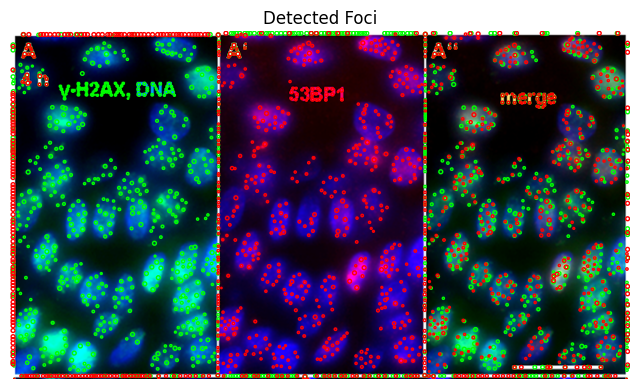

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import blob_log

# Load image
img = cv2.imread('D:/Test IF.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Split channels
red = img[:, :, 0]
green = img[:, :, 1]
blue = img[:, :, 2]  # nuclei (optional)

# Normalize
green_norm = cv2.normalize(green, None, 0, 255, cv2.NORM_MINMAX)
red_norm = cv2.normalize(red, None, 0, 255, cv2.NORM_MINMAX)

# --- Detect green foci ---
green_blobs = blob_log(
    green_norm,
    min_sigma=2,
    max_sigma=6,
    num_sigma=10,
    threshold=0.05
)

# --- Detect red foci ---
red_blobs = blob_log(
    red_norm,
    min_sigma=2,
    max_sigma=6,
    num_sigma=10,
    threshold=0.05
)

print(f"Green foci count: {len(green_blobs)}")
print(f"Red foci count: {len(red_blobs)}")

# --- Visualization ---
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(img)

# Draw green circles
for blob in green_blobs:
    y, x, r = blob
    c = plt.Circle((x, y), r, color='lime', linewidth=1, fill=False)
    ax.add_patch(c)

# Draw red circles
for blob in red_blobs:
    y, x, r = blob
    c = plt.Circle((x, y), r, color='red', linewidth=1, fill=False)
    ax.add_patch(c)

plt.title("Detected Foci")
plt.axis('off')
plt.show()

Green foci count: 1605
Red foci count: 1572


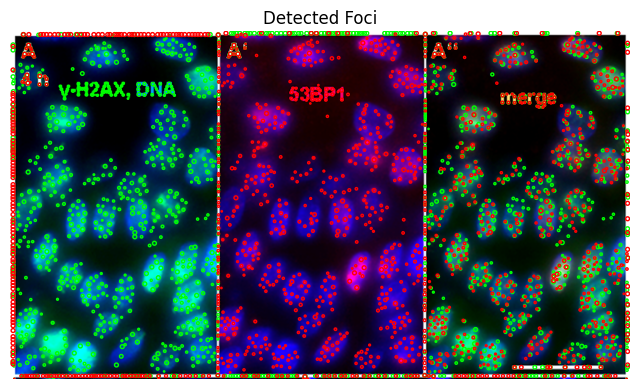

In [ ]:
green_blobs = blob_log(
    green_norm,
    num_sigma=10,
    min_sigma=2,      # smaller = detect tiny foci
    max_sigma=6,      # larger = detect bigger foci
    threshold=0.03    # sensitivity
)

red_blobs = blob_log(
    red_norm,
    num_sigma=10,
    min_sigma=2,      # smaller = detect tiny foci
    max_sigma=6,      # larger = detect bigger foci
    threshold=0.03    # sensitivity
)

print(f"Green foci count: {len(green_blobs)}")
print(f"Red foci count: {len(red_blobs)}")

# --- Visualization ---
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(img)

# Draw green circles
for blob in green_blobs:
    y, x, r = blob
    c = plt.Circle((x, y), r, color='lime', linewidth=1, fill=False)
    ax.add_patch(c)

# Draw red circles
for blob in red_blobs:
    y, x, r = blob
    c = plt.Circle((x, y), r, color='red', linewidth=1, fill=False)
    ax.add_patch(c)

plt.title("Detected Foci")
plt.axis('off')
plt.show()

In [ ]:
# Nucleus-wise counting (DAPI segmentation)
# AI upgrade using Cellpose (no training needed)
# Co-localization (green + red overlap)

In [ ]:
!pip install cellpose

In [ ]:
pip show cellpose

Name: cellpose
Version: 4.0.8
Summary: anatomical segmentation algorithm
Home-page: https://github.com/MouseLand/cellpose
Author: Marius Pachitariu and Carsen Stringer
Author-email: stringerc@janelia.hhmi.org
License: BSD
Location: C:\Users\HS_Hu\anaconda3\Lib\site-packages
Requires: fastremap, fill-voids, imagecodecs, natsort, numpy, opencv-python-headless, roifile, scipy, segment_anything, tifffile, torch, torchvision, tqdm
Required-by: 
Note: you may need to restart the kernel to use updated packages.


Total green foci: 1348
Total red foci: 1327
Detected nuclei: 36


   Nucleus  Green_foci  Red_foci
0        1        1012      1024
1        2          12        21
2        3           0        17
3        4          15         0
4        5           9         9


100%|██████████| 1.15G/1.15G [00:08<00:00, 154MB/s]


Cellpose nuclei detected: 82
Colocalized pixels: 115993


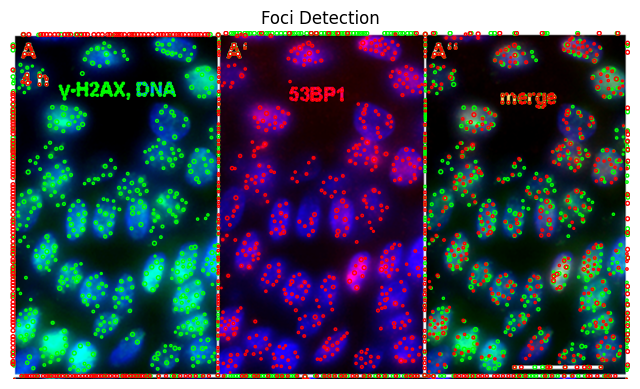

Saved: foci_per_nucleus.csv


In [3]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import blob_log
from skimage.measure import label, regionprops
from cellpose import models

# -----------------------------
# 1. LOAD IMAGE
# -----------------------------
img = cv2.imread('/content/Test IF.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Split channels
red = img[:, :, 0]
green = img[:, :, 1]
blue = img[:, :, 2]   # nuclei (DAPI)

# Normalize
green_norm = cv2.normalize(green, None, 0, 255, cv2.NORM_MINMAX)
red_norm = cv2.normalize(red, None, 0, 255, cv2.NORM_MINMAX)

# -----------------------------
# 2. DETECT FOCI (BLOB)
# -----------------------------
green_blobs = blob_log(green_norm, min_sigma=2, max_sigma=6, threshold=0.05)
red_blobs   = blob_log(red_norm,   min_sigma=2, max_sigma=6, threshold=0.05)

print("Total green foci:", len(green_blobs))
print("Total red foci:", len(red_blobs))

# -----------------------------
# 3. NUCLEI SEGMENTATION (CLASSICAL)
# -----------------------------
_, nuclei_mask = cv2.threshold(blue, 50, 255, cv2.THRESH_BINARY)

# Clean mask
kernel = np.ones((3,3), np.uint8)
nuclei_mask = cv2.morphologyEx(nuclei_mask, cv2.MORPH_OPEN, kernel)

labels = label(nuclei_mask)
print("Detected nuclei:", labels.max())

# -----------------------------
# 4. NUCLEUS-WISE FOCI COUNT
# -----------------------------
results = []

for region in regionprops(labels):
    nucleus_id = region.label
    coords = region.coords

    # Create mask for this nucleus
    mask = np.zeros(labels.shape, dtype=bool)
    mask[coords[:,0], coords[:,1]] = True

    # Count green foci in this nucleus
    g_count = sum(mask[int(y), int(x)] for y, x, r in green_blobs)

    # Count red foci
    r_count = sum(mask[int(y), int(x)] for y, x, r in red_blobs)

    results.append([nucleus_id, g_count, r_count])

df = pd.DataFrame(results, columns=["Nucleus", "Green_foci", "Red_foci"])
print(df.head())

# # -----------------------------
# # 5. AI SEGMENTATION (CELLPOSE)
# # -----------------------------
# model = models.Cellpose(model_type='nuclei')

# masks, flows, styles, diams = model.eval(blue, channels=[0,0])

# print("Cellpose nuclei detected:", masks.max())

# -----------------------------
# 5. AI SEGMENTATION (CELLPOSE) - FIXED
# -----------------------------
model = models.CellposeModel(gpu=True, model_type='nuclei')

# model = models.CellposeModel(pretrained_model='nuclei')

masks, flows, styles = model.eval(blue, channels=[0,0])

print("Cellpose nuclei detected:", masks.max())

# -----------------------------
# 6. CO-LOCALIZATION
# -----------------------------
green_bin = green_norm > 100
red_bin   = red_norm > 100

colocalized = np.logical_and(green_bin, red_bin)

print("Colocalized pixels:", np.sum(colocalized))

# -----------------------------
# 7. VISUALIZATION
# -----------------------------
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(img)

# Draw green blobs
for y, x, r in green_blobs:
    c = plt.Circle((x, y), r, color='lime', fill=False, linewidth=1)
    ax.add_patch(c)

# Draw red blobs
for y, x, r in red_blobs:
    c = plt.Circle((x, y), r, color='red', fill=False, linewidth=1)
    ax.add_patch(c)

plt.title("Foci Detection")
plt.axis('off')
plt.show()

# -----------------------------
# 8. SAVE RESULTS
# -----------------------------
df.to_csv("foci_per_nucleus.csv", index=False)
print("Saved: foci_per_nucleus.csv")